Inference after the 10x epochs and 5 models

In [1]:
# import siamese_torch2 as st 
import siamese_models as sm 

import matplotlib.pyplot as plt
import utils as ut
import torch
import torch.nn as nn

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np

2025-01-16 10:28:06.535862: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-16 10:28:06.547246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737019686.561189 2271388 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737019686.565395 2271388 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-16 10:28:06.579883: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [26]:
m = nn.Sigmoid()
loss = nn.BCELoss()
input = torch.randn(3, 2, requires_grad=True)
target = torch.rand(3, 2, requires_grad=False)
output = loss(m(input), target)
output.backward()

In [27]:
one = torch.tensor([0.5250, 0.6626, 0.5120, 0.3428, 0.5389, 0.2795, 0.6947, 0.6193, 0.4644,
        0.5834, 0.5480, 0.3622, 0.6111, 0.5253, 0.1781, 0.1566, 0.6235, 0.6395,
        0.3598, 0.7558, 0.2645, 0.9346, 0.2789, 0.2427, 0.3734, 0.4342, 0.5374,
        0.8769, 0.3195, 0.6251, 0.5068, 0.5755])
two = torch.tensor([1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1.,
        0., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1.])

nn.BCELoss()(one, two)

tensor(0.5857)

In [28]:
models = {
    'ResNet': sm.SiameseNetworkResnet(),
    'MobileNet': sm.SiameseNetworkMobnet(),
    'ResNeXt': sm.SiameseNetworkNext(),
    'VGGNet': sm.SiameseNetworkVGGnet(),
    'EfficientNet': sm.SiameseNetworkEffnet()
}

In [29]:
for m in models:
    print(m)

ResNet
MobileNet
ResNeXt
VGGNet
EfficientNet


In [30]:
m(input), target

TypeError: 'str' object is not callable

In [7]:
s1 = sm.SiameseNetworkResnet()
s2 = sm.SiameseNetworkResnet()

for p1, p2 in zip(s1.parameters(), s2.parameters()):
    if p1.data.ne(p2.data).sum() > 0:
        print(False)
print(True)

False
False
False
True


In [2]:
ds_folds = ut.siamese_noise_dataset_fold2(test_size=0.1,shuffle=True, noise_size='big', n_splits=5)

Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674


In [9]:
ds_folds

[DatasetDict({
     train: Dataset({
         features: ['slice1', 'slice2', 'label', 'image_type'],
         num_rows: 2266
     })
     valid: Dataset({
         features: ['slice1', 'slice2', 'label', 'image_type'],
         num_rows: 568
     })
     test: Dataset({
         features: ['slice1', 'slice2', 'label', 'image_type'],
         num_rows: 316
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['slice1', 'slice2', 'label', 'image_type'],
         num_rows: 2266
     })
     valid: Dataset({
         features: ['slice1', 'slice2', 'label', 'image_type'],
         num_rows: 568
     })
     test: Dataset({
         features: ['slice1', 'slice2', 'label', 'image_type'],
         num_rows: 316
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['slice1', 'slice2', 'label', 'image_type'],
         num_rows: 2268
     })
     valid: Dataset({
         features: ['slice1', 'slice2', 'label', 'image_type'],
         num_rows: 566
     })
     tes

Visualize tsne

In [10]:
ds_folds[0]['test']

Dataset({
    features: ['slice1', 'slice2', 'label', 'image_type'],
    num_rows: 316
})

In [ ]:
for i in range(10):
    display(ds_folds[0]['test'][i]['slice1'], ds_folds[0]['test'][i]['slice2'])

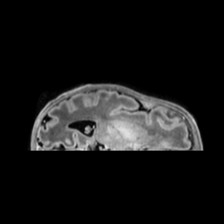

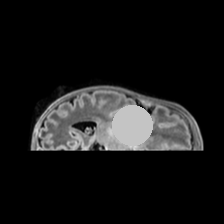

In [3]:
 display(im1:=ds_folds[0]['test'][2]['slice1'], im2:=ds_folds[0]['test'][2]['slice2'])

In [21]:
train_loader = torch.utils.data.DataLoader(ds_folds[0]['train'].with_format("torch"), batch_size=32)
test_loader = torch.utils.data.DataLoader(ds_folds[0]['test'].with_format("torch"), batch_size=32)
next(iter(test_loader))['slice1'].shape

torch.Size([32, 1, 224, 224])

In [15]:
next(iter(test_loader))['slice1'][3][0].shape

torch.Size([224, 224])

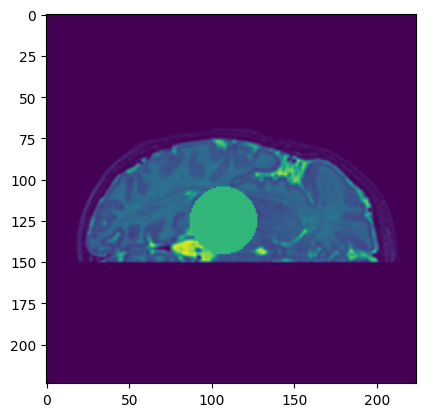

torch.Size([1, 224, 1, 224])

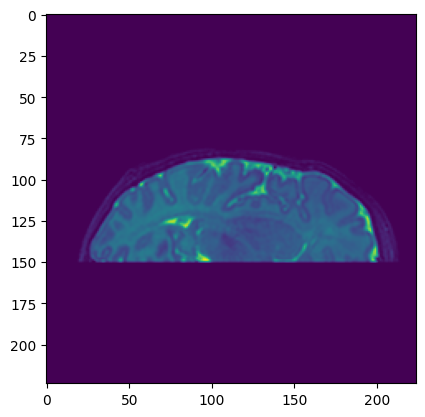

In [72]:
import matplotlib.pyplot as plt

plt.imshow(next(iter(test_loader))['slice1'][3][0])
plt.show()
plt.imshow(next(iter(test_loader))['slice2'][3][0])

im1 = next(iter(test_loader))['slice1'][2]
im2 = next(iter(test_loader))['slice2'][2]
im1.to("cuda:2", dtype=torch.float32).unsqueeze(2).shape
im2.to("cuda:2", dtype=torch.float32).unsqueeze(2).shape

In [17]:
test_loader

In [3]:
# pathres = "models/kfold2big/SiameseNetworkResnet.pt"
pathres = "models/kfoldtest_big/ResNet.pt"
# pathvgg = "models/kfold2big/SiameseNetworkVGGnet.pt"
pathvgg = "models/kfoldtest_lil2/VGGNet_train9_fold2.pt"

resnet = sm.SiameseNetworkResnet()
resnet.load_state_dict(torch.load(pathres))
resnet.eval()
resnet.to("cuda:2")

vggnet = sm.SiameseNetworkVGGnet()
vggnet.load_state_dict(torch.load(pathvgg))
vggnet.eval()
vggnet.to("cuda:2")
print("ok")

/tmp/ipykernel_2271388/2976820875.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet.load_state_dict(torch.load(pathres))
/tmp/ipykernel_2271388/2976820875.py:12: Fu

ok


In [23]:
with torch.no_grad():
    for i, data in enumerate(test_loader):
        if i >= 1: break
        im1 = data['slice1'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
        im2 = data['slice2'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
        targets = data['label'].to("cuda:2", dtype=torch.float32)
        print(im1.view(1, 32, 224, 224).shape)

torch.Size([1, 32, 224, 224])


In [27]:
with torch.no_grad():
    for i, data in enumerate(test_loader):
        if i >= 1: break
        im1 = data['slice1'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
        im2 = data['slice2'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
        targets = data['label'].to("cuda:2", dtype=torch.float32)

        # Resnet
        feat1 = resnet.forward_once(im1.view(32, 1, 224, 224))
        feat2 = resnet.forward_once(im2.view(32, 1, 224, 224))
        combined_features = torch.cat((feat1, feat2), dim=1)

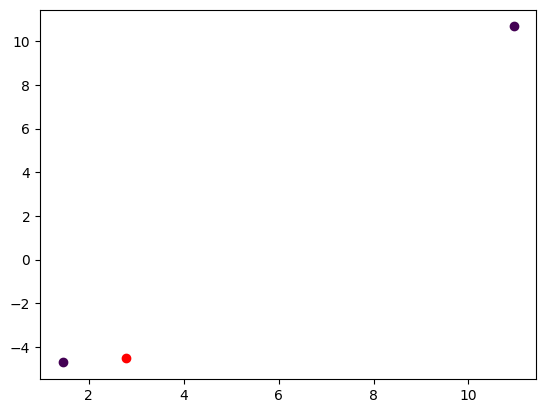

In [28]:
reduced_combined = PCA(n_components=2 ).fit_transform(feat1.cpu().numpy())
labels = np.array(targets.cpu().numpy())

plt.scatter(reduced_combined[0, 0], reduced_combined[0, 1], c="red")
plt.scatter(reduced_combined[2, 0], reduced_combined[2, 1], c=labels[2])
plt.scatter(reduced_combined[3, 0], reduced_combined[3, 1], c=labels[3])

plt.show()

In [68]:
vggnet.vggnet
# vggnet.classifier[0].in_features

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [20]:
test_loader

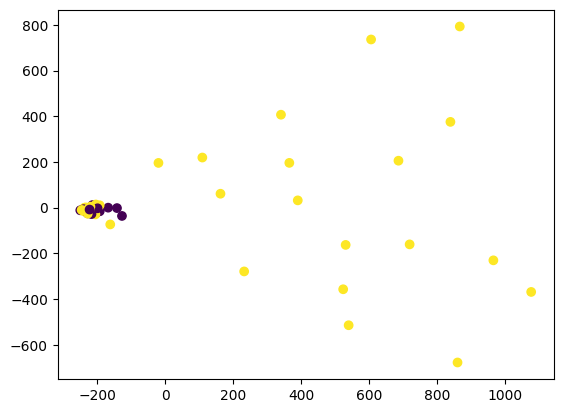

In [19]:
from sklearn.manifold import TSNE

with torch.no_grad():
    for i, data in enumerate(test_loader):
        if i >= 1: break
        im1 = data['slice1'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
        im2 = data['slice2'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
        targets = data['label'].to("cuda:2", dtype=torch.float32)

        # Resnet
        # feat1 = resnet.forward_once(im1.view(32, 1, 224, 224))
        # feat2 = resnet.forward_once(im2.view(32, 1, 224, 224))
        # combined_features = torch.cat((feat1, feat2), dim=1)

        # reduced_feat1 = PCA(n_components=2, random_state=0).fit_transform(feat1.cpu().numpy())
        # reduced_feat2 = PCA(n_components=2, random_state=0).fit_transform(feat2.cpu().numpy())
        # labels = np.array(targets.cpu().numpy())

        # plt.scatter(reduced_feat1[:, 0], reduced_feat1[:, 1], c=labels)
        # plt.scatter(reduced_feat2[:, 0], reduced_feat2[:, 1], c=labels)
        # plt.show()

        # Vggnet
        feat1 = vggnet.forward_once(im1.view(32, 1, 224, 224))
        feat2 = vggnet.forward_once(im2.view(32, 1, 224, 224))
        # feat1 = vggnet.forward_once(im1[0])
        # feat2 = vggnet.forward_once(im2[0])

        reduced_feat1 = PCA(n_components=2, random_state=0).fit_transform(feat1.cpu().numpy())
        reduced_feat2 = PCA(n_components=2, random_state=0).fit_transform(feat2.cpu().numpy())
        labels = np.array(targets.cpu().numpy())

        plt.scatter(reduced_feat1[:, 0], reduced_feat1[:, 1], c=labels)
        plt.scatter(reduced_feat2[:, 0], reduced_feat2[:, 1], c=labels)
        plt.show()

        # TSNE
        # reduced_feat1 = TSNE(n_components=2, random_state=0).fit_transform(feat1.cpu().numpy())
        # reduced_feat2 = TSNE(n_components=2, random_state=0).fit_transform(feat2.cpu().numpy())
        # labels = np.array(targets.cpu().numpy())

        # plt.scatter(reduced_feat1[:, 0], reduced_feat1[:, 1], c=labels)
        # plt.scatter(reduced_feat2[:, 0], reduced_feat2[:, 1], c=labels)
        # plt.show()

In [22]:
next(iter(train_loader))

{'slice1': tensor([[[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]],
 
 
         [[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]],
 
 
         [[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]],
 
 
         ...,
 
 
         [[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]],


In [24]:

with torch.no_grad():
    for i, data in enumerate(train_loader):
        # if i >= 1: break
        im1 = data['slice1'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
        im2 = data['slice2'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
        print(im1.shape)

torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size([32, 1, 1, 224, 224])
torch.Size

In [34]:
len(train_loader[0]

TypeError: 'DataLoader' object is not subscriptable

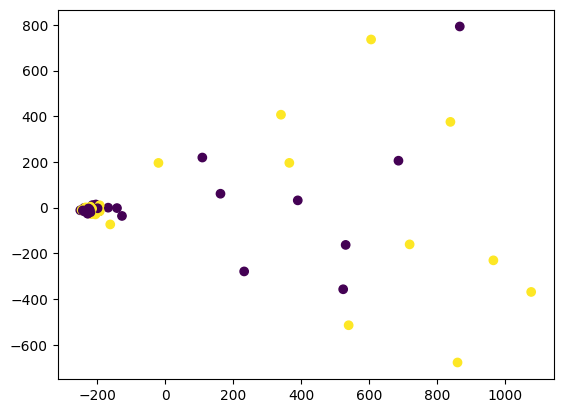

In [39]:
all_feats  = []
all_feats1 = []
all_feats2 = []
j = 0
with torch.no_grad():
    for i, data in enumerate(train_loader):
        while j < 70:

            # if i >= 1: break
            im1 = data['slice1'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
            im2 = data['slice2'].to("cuda:2", dtype=torch.float32).unsqueeze(1)
            targets = data['label'].to("cuda:2", dtype=torch.float32)

            feat1s = vggnet.forward_once(im1.view(im1.shape[0], 1, 224, 224))
            feat1s = feat1s.view(feat1s.size(0), -1)
            feat2s = vggnet.forward_once(im2.view(im2.shape[0], 1, 224, 224))
            feat2s = feat2s.view(feat2s.size(0), -1)

            all_feats1.append(feat1s.cpu().numpy())
            all_feats2.append(feat2s.cpu().numpy())

            j+=1

all_feats1 = np.concatenate(all_feats1, axis=0)
all_feats2 = np.concatenate(all_feats2, axis=0)
# pca = PCA(n_components=2, random_state=0)

reduced_feat1 = PCA(n_components=2, random_state=0).fit_transform(feat1.cpu().numpy())
reduced_feat2 = PCA(n_components=2, random_state=0).fit_transform(feat2.cpu().numpy())
labels = np.array(targets.cpu().numpy())

plt.scatter(reduced_feat1[:, 0], reduced_feat1[:, 1], c=labels)
plt.scatter(reduced_feat2[:, 0], reduced_feat2[:, 1], c=labels)
plt.show()

In [37]:
im1.shape

torch.Size([26, 1, 1, 224, 224])

In [100]:
feat1.shape

torch.Size([1, 25088])

In [96]:
im1[31].shape

torch.Size([1, 1, 224, 224])

In [ ]:
def visualize_tsne(model, device, test_loader, epoch, wandb=True):
    """
        Attempt at embeddings(after siamese pass) visualization with dim reduction. 
    """
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for i in test_loader:
            images_1 = i['slice1'].to(device, dtype=torch.float32).unsqueeze(1)
            images_2 = i['slice2'].to(device, dtype=torch.float32).unsqueeze(1)
            targets = i['label'].to(device, dtype=torch.float32)

            # Extract features
            feat1 = model.forward_once(images_1)
            feat2 = model.forward_once(images_2)
            combined_features = torch.cat((feat1, feat2), dim=1)

            features.extend(combined_features.cpu().numpy())
            labels.extend(targets.cpu().numpy())

    features = np.array(features)
    labels = np.array(labels)

    # t-SNE Visualization
    tsne = TSNE(n_components=2, random_state=0)
    reduced_features = tsne.fit_transform(features)
    print(reduced_features.shape)

    # plt.figure(figsize=(10, 8))
    fig, axes = plt.subplots(3, 1, figsize=(20, 8))
    scatter = axes[0].scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap='viridis')
    axes[0].set_title(f't-SNE Visualization - Epoch {epoch}')
    axes[1].imshow(images_1[0].cpu().squeeze().numpy())
    axes[1].set_title(f'image 1 - Epoch {epoch}')
    axes[2].imshow(images_2[0].cpu().squeeze().numpy())
    axes[2].set_title(f'image 2 - Epoch {epoch}')
    plt.colorbar(scatter)
    plt.savefig(f'tsneepoch{epoch}.png')
    plt.close()

    # Feature Importance (assuming the last layer is named 'fc')
    importance = model.fc[-1].weight.abs().cpu().detach().numpy()
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(importance[0])), importance[0])
    plt.title(f'Feature Importance - Epoch {epoch}')
    plt.savefig(f'feature_importanceepoch{epoch}.png')
    plt.close()

# 1. ResNet, test 1

In [5]:
pathres = "models/kfoldlil/SiameseNetworkResnet.pt"

resnet = st.SiameseNetworkResnet()
resnet.load_state_dict(torch.load(pathres))
resnet.eval()
resnet.to("cuda:2")

SiameseNetworkResnet(
  (resnet): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

In [4]:
ds_folds = ut.siamese_noise_dataset_fold2(shuffle=True, noise_size='big', n_splits=5)
testloaderbig = torch.utils.data.DataLoader(ds_folds[0]['test'].with_format("torch"), batch_size=32)

Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674


In [10]:
test_loss, test_metrics = st.test(resnet, "cuda:2", testloaderbig)

print(f"\nFinal Test Results for: {resnet.__class__.__name__}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test Precision: {test_metrics['precision']:.4f}")
print(f"Test Recall: {test_metrics['recall']:.4f}")
print(f"Test F1 Score: {test_metrics['f1']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])


Val set: Average loss: 14.0714
Accuracy: 0.5587
Precision: 0.5415
Recall: 0.5770
F1 Score: 0.5587
Confusion Matrix:
[[176 149]
 [129 176]]

Final Test Results for: SiameseNetworkResnet
Test Loss: 14.0714
Test Accuracy: 0.5587
Test Precision: 0.5415
Test Recall: 0.5770
Test F1 Score: 0.5587
Confusion Matrix:
[[176 149]
 [129 176]]


# 2. VGGNet

In [ ]:
pathvgg = "models/kfoldlil/SiameseNetworkVGGnet.pt"

vggnet = st.SiameseNetworkVGGnet()
vggnet.load_state_dict(torch.load(pathvgg))
vggnet.eval()
vggnet.to("cuda:2")

In [13]:
test_loss, test_metrics = st.test(vggnet, "cuda:2", testloaderbig)

print(f"\nFinal Test Results for: {vggnet.__class__.__name__}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test Precision: {test_metrics['precision']:.4f}")
print(f"Test Recall: {test_metrics['recall']:.4f}")
print(f"Test F1 Score: {test_metrics['f1']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])


Val set: Average loss: 12.3680
Accuracy: 0.6778
Precision: 0.6474
Recall: 0.7344
F1 Score: 0.6882
Confusion Matrix:
[[203 122]
 [ 81 224]]

Final Test Results for: SiameseNetworkVGGnet
Test Loss: 12.3680
Test Accuracy: 0.6778
Test Precision: 0.6474
Test Recall: 0.7344
Test F1 Score: 0.6882
Confusion Matrix:
[[203 122]
 [ 81 224]]


In [4]:
import siamese_torch2 as st 
import utils as ut
import torch
import pandas as pd

def evaluate_model(model, device, test_loader):
    model.eval()
    model.to(device)
    test_loss, test_metrics = st.test(model, device, test_loader)
    return test_metrics['accuracy']

def load_model(model_class, path, device):
    model = model_class()
    model.load_state_dict(torch.load(path))
    model.to(device)
    return model


# Define model paths and classes
models = [
    ("Resnet", st.SiameseNetworkResnet, "models/kfold2mid/SiameseNetworkResnet.pt"),
    ("ResneXt", st.SiameseNetworkNext, "models/kfold2mid/SiameseNetworkNext.pt"),
    ("VGGNet", st.SiameseNetworkVGGnet, "models/kfold2mid/SiameseNetworkVGGnet.pt"),
    ("Mobnet", st.SiameseNetworkMobnet, "models/kfold2mid/SiameseNetworkMobnet.pt"),
    ("EfficientNet", st.SiameseNetworkEffnet, "models/kfold2mid/SiameseNetworkEffnet.pt"),
]

# Define noise levels
noise_levels = ['lil', 'mid', 'big']

# Initialize results dictionary
results = {model_name: {} for model_name, _, _ in models}

device = "cuda:2"

# Evaluate each model on each noise level
for noise_level in noise_levels:
    ds_folds = ut.siamese_noise_dataset_fold2(noise_size=noise_level, n_splits=5)
    test_loader = torch.utils.data.DataLoader(ds_folds[0]['test'].with_format("torch"), batch_size=32)

    for model_name, model_class, model_path in models:
        model = load_model(model_class, model_path, device)
        accuracy = evaluate_model(model, device, test_loader)
        results[model_name][noise_level] = accuracy

        print(f"{noise_level} {model_name} done")

# Create a pandas DataFrame from the results
df = pd.DataFrame(results).T

# Print the results table
print("\nAccuracy Results:")
print(df.to_string())

# Optionally, save the results to a CSV file
# df.to_csv("model_evaluation_results.csv")

Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674
lil Resnet done


KeyboardInterrupt: 

**BIG**

In [2]:
import siamese_models as sm
import siamese_torch2 as st
import utils as ut
import torch
import pandas as pd

def evaluate_model(model, device, test_loader):
    model.eval()
    model.to(device)
    test_loss, test_metrics = st.test(model, device, test_loader)
    return test_metrics['accuracy']

def load_model(model_class, path, device):
    model = model_class()
    model.load_state_dict(torch.load(path))
    model.to(device)
    return model

# Define model paths and classes
models = [
    ("Resnet", sm.SiameseNetworkResnet, "models/kfold2big/ResNet.pt"),
    ("ResneXt", sm.SiameseNetworkNext, "models/kfold2big/ResNeXt.pt"),
    ("VGGNet", sm.SiameseNetworkVGGnet, "models/kfold2big/VGGNet.pt"),
    ("Mobnet", sm.SiameseNetworkMobnet, "models/kfold2big/MobileNet.pt"),
    ("EfficientNet", sm.SiameseNetworkEffnet, "models/kfold2big/EffNet.pt"),
]

# Define noise levels
noise_levels = ['lil', 'mid', 'big']

# Initialize results dictionary
results = {model_name: {} for model_name, _, _ in models}

device = "cuda:2"

# Evaluate each model on each noise level
for noise_level in noise_levels:
    print(f"EVALUATION ON {noise_level}")
    ds_folds = ut.siamese_noise_dataset_fold2(noise_size=noise_level, n_splits=5)
    test_loader = torch.utils.data.DataLoader(ds_folds[0]['test'].with_format("torch"), batch_size=32)

    for model_name, model_class, model_path in models:
        model = load_model(model_class, model_path, device)
        accuracy = evaluate_model(model, device, test_loader)
        results[model_name][noise_level] = accuracy

# Create a pandas DataFrame from the results
df = pd.DataFrame(results).T

# Print the results table
print("\nAccuracy Results:")
print(df.to_string())

# Optionally, save the results to a CSV file
# df.to_csv("model_evaluation_results.csv")

EVALUATION ON lil
Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674


/home/arnaud/miniconda3/envs/mri/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Val set: Average loss: 28.8244
Accuracy: 0.5159
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Confusion Matrix:
[[325   0]
 [305   0]]

Val set: Average loss: 14.2415
Accuracy: 0.5238
Precision: 0.5089
Recall: 0.4689
F1 Score: 0.4881
Confusion Matrix:
[[187 138]
 [162 143]]

Val set: Average loss: 50.3094
Accuracy: 0.5190
Precision: 1.0000
Recall: 0.0066
F1 Score: 0.0130
Confusion Matrix:
[[325   0]
 [303   2]]

Val set: Average loss: 13.7280
Accuracy: 0.5587
Precision: 0.6154
Recall: 0.2361
F1 Score: 0.3412
Confusion Matrix:
[[280  45]
 [233  72]]

Val set: Average loss: 14.0025
Accuracy: 0.5270
Precision: 0.5455
Recall: 0.1377
F1 Score: 0.2199
Confusion Matrix:
[[290  35]
 [263  42]]
EVALUATION ON mid
Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674

Val set: Average loss: 24.9022
Accuracy: 0.5190
Precision: 1.0000
Recall: 0.0066
F1 Score: 0.0130
Confusion Matrix:
[[325   0]
 [303   2]]

Val set: Average loss: 13.9415
Accuracy: 0.5413
Precision: 0.527

**MID**

In [3]:
import siamese_models as sm
import siamese_torch2 as st
import utils as ut
import torch
import pandas as pd

def evaluate_model(model, device, test_loader):
    model.eval()
    model.to(device)
    test_loss, test_metrics = st.test(model, device, test_loader)
    return test_metrics['accuracy']

def load_model(model_class, path, device):
    model = model_class()
    model.load_state_dict(torch.load(path))
    model.to(device)
    return model

# Define model paths and classes
models = [
    ("Resnet", sm.SiameseNetworkResnet, "models/kfold2mid/ResNet.pt"),
    ("ResneXt", sm.SiameseNetworkNext, "models/kfold2mid/ResNeXt.pt"),
    ("VGGNet", sm.SiameseNetworkVGGnet, "models/kfold2mid/VGGNet.pt"),
    ("Mobnet", sm.SiameseNetworkMobnet, "models/kfold2mid/MobileNet.pt"),
    ("EfficientNet", sm.SiameseNetworkEffnet, "models/kfold2mid/EffNet.pt"),
]

# Define noise levels
noise_levels = ['lil', 'mid', 'big']

# Initialize results dictionary
results = {model_name: {} for model_name, _, _ in models}

device = "cuda:2"

# Evaluate each model on each noise level
for noise_level in noise_levels:
    print(f"EVALUATION ON {noise_level}")
    ds_folds = ut.siamese_noise_dataset_fold2(noise_size=noise_level, n_splits=5)
    test_loader = torch.utils.data.DataLoader(ds_folds[0]['test'].with_format("torch"), batch_size=32)

    for model_name, model_class, model_path in models:
        model = load_model(model_class, model_path, device)
        accuracy = evaluate_model(model, device, test_loader)
        results[model_name][noise_level] = accuracy

# Create a pandas DataFrame from the results
df = pd.DataFrame(results).T

# Print the results table
print("\nAccuracy Results:")
print(df.to_string())

# Optionally, save the results to a CSV file
# df.to_csv("model_evaluation_results.csv")

EVALUATION ON lil
Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674

Val set: Average loss: 13.4454
Accuracy: 0.6270
Precision: 0.6446
Recall: 0.5115
F1 Score: 0.5704
Confusion Matrix:
[[239  86]
 [149 156]]

Val set: Average loss: 14.0805
Accuracy: 0.5095
Precision: 0.4934
Recall: 0.4918
F1 Score: 0.4926
Confusion Matrix:
[[171 154]
 [155 150]]

Val set: Average loss: 17.5013
Accuracy: 0.6556
Precision: 0.8333
Recall: 0.3607
F1 Score: 0.5034
Confusion Matrix:
[[303  22]
 [195 110]]

Val set: Average loss: 13.7512
Accuracy: 0.5413
Precision: 0.5263
Recall: 0.5246
F1 Score: 0.5255
Confusion Matrix:
[[181 144]
 [145 160]]

Val set: Average loss: 13.8647
Accuracy: 0.5016
Precision: 0.4681
Recall: 0.2164
F1 Score: 0.2960
Confusion Matrix:
[[250  75]
 [239  66]]
EVALUATION ON mid
Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674

Val set: Average loss: 11.4653
Accuracy: 0.7079
Precision: 0.7065
Recall: 0.6787
F1 Score: 0.6923
Confusion M

In [4]:
import siamese_models as sm
import siamese_torch2 as st
import utils as ut
import torch
import pandas as pd

def evaluate_model(model, device, test_loader):
    model.eval()
    model.to(device)
    test_loss, test_metrics = st.test(model, device, test_loader)
    return test_metrics['accuracy']

def load_model(model_class, path, device):
    model = model_class()
    model.load_state_dict(torch.load(path))
    model.to(device)
    return model

# Define model paths and classes
models = [
    ("Resnet", sm.SiameseNetworkResnet, "models/kfold2lil/ResNet.pt"),
    ("ResneXt", sm.SiameseNetworkNext, "models/kfold2lil/ResNeXt.pt"),
    ("VGGNet", sm.SiameseNetworkVGGnet, "models/kfold2lil/VGGNet.pt"),
    ("Mobnet", sm.SiameseNetworkMobnet, "models/kfold2lil/MobileNet.pt"),
    ("EfficientNet", sm.SiameseNetworkEffnet, "models/kfold2lil/EffNet.pt"),
]

# Define noise levels
noise_levels = ['lil', 'mid', 'big']

# Initialize results dictionary
results = {model_name: {} for model_name, _, _ in models}

device = "cuda:2"

# Evaluate each model on each noise level
for noise_level in noise_levels:
    print(f"EVALUATION ON {noise_level}")
    ds_folds = ut.siamese_noise_dataset_fold2(noise_size=noise_level, n_splits=5)
    test_loader = torch.utils.data.DataLoader(ds_folds[0]['test'].with_format("torch"), batch_size=32)

    for model_name, model_class, model_path in models:
        model = load_model(model_class, model_path, device)
        accuracy = evaluate_model(model, device, test_loader)
        results[model_name][noise_level] = accuracy

# Create a pandas DataFrame from the results
df = pd.DataFrame(results).T

# Print the results table
print("\nAccuracy Results:")
print(df.to_string())

# Optionally, save the results to a CSV file
# df.to_csv("model_evaluation_results.csv")

EVALUATION ON lil
Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674

Val set: Average loss: 13.3275
Accuracy: 0.5857
Precision: 0.5991
Recall: 0.4361
F1 Score: 0.5047
Confusion Matrix:
[[236  89]
 [172 133]]

Val set: Average loss: 14.0991
Accuracy: 0.4778
Precision: 0.4610
Recall: 0.4656
F1 Score: 0.4633
Confusion Matrix:
[[159 166]
 [163 142]]

Val set: Average loss: 9.4679
Accuracy: 0.7444
Precision: 0.7338
Recall: 0.7410
F1 Score: 0.7374
Confusion Matrix:
[[243  82]
 [ 79 226]]

Val set: Average loss: 13.7375
Accuracy: 0.5381
Precision: 0.5245
Recall: 0.4918
F1 Score: 0.5076
Confusion Matrix:
[[189 136]
 [155 150]]

Val set: Average loss: 13.8466
Accuracy: 0.5254
Precision: 0.5484
Recall: 0.1115
F1 Score: 0.1853
Confusion Matrix:
[[297  28]
 [271  34]]
EVALUATION ON mid
Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674

Val set: Average loss: 13.1530
Accuracy: 0.5889
Precision: 0.6027
Recall: 0.4426
F1 Score: 0.5104
Confusion Ma

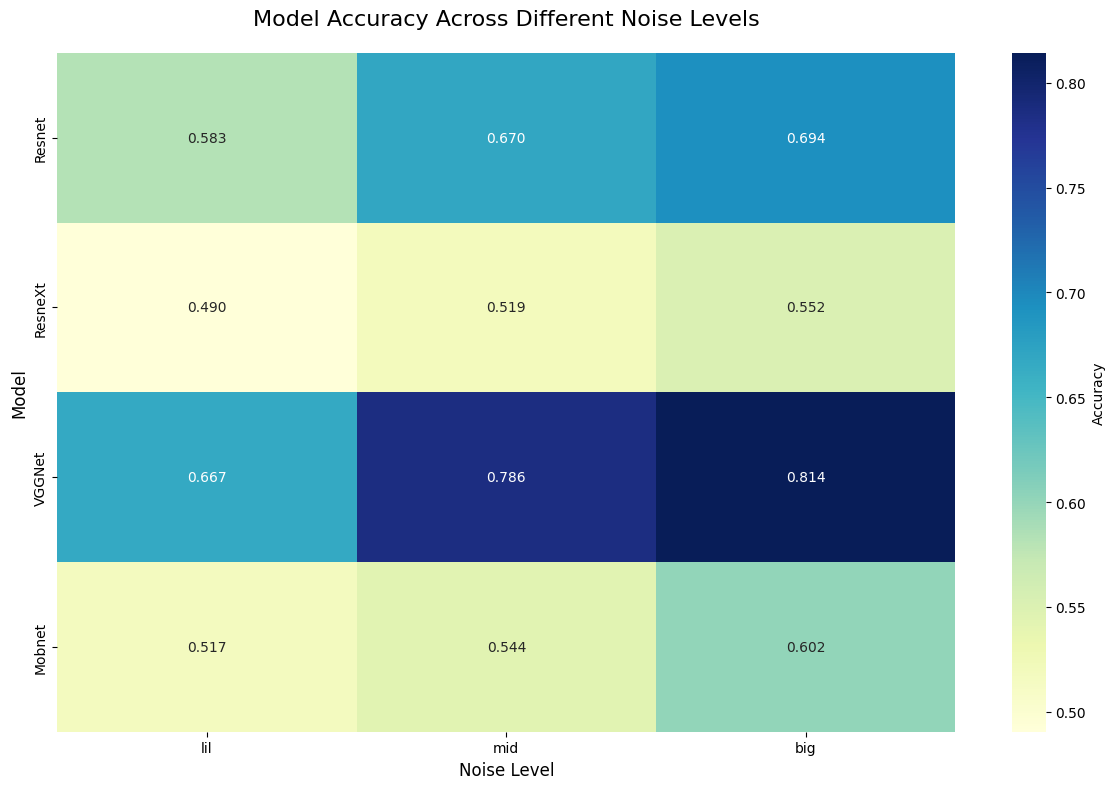

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming we have our results DataFrame 'df' from the previous script
# If not, you can load it from the CSV file:
# df = pd.read_csv("model_evaluation_results.csv", index_col=0)

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Create the heatmap
heatmap = sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".3f", cbar_kws={'label': 'Accuracy'})

# Customize the plot
plt.title("Model Accuracy Across Different Noise Levels", fontsize=16, pad=20)
plt.xlabel("Noise Level", fontsize=12)
plt.ylabel("Model", fontsize=12)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=0)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Save the figure
# plt.savefig("model_accuracy_heatmap.png", dpi=300, bbox_inches="tight")

# Display the plot (optional, remove this line if running on a server without display)
plt.show()